# 02. Perfect Foresight & Deterministic Transitions in `dyno.py`

In macroeconomics, many questions involve **deterministic simulations** (perfect foresight) rather than stochastic perturbations:
- Anticipated future policy changes (e.g. pre-announced tax reforms).
- Large transition paths away from steady state where linearization errors would be severe (e.g. demographic shifts, post-crisis recovery, climate transitions).
- Temporary or permanent structural shocks.

In this notebook, we demonstrate how `dyno.py` handles deterministic models:
1. **Specifying Deterministic Models**: Initial conditions and anticipated shock paths.
2. **Stacked-Time Boundary Value Problem**: How Dyno solves the non-linear system.
3. **Solving with `deterministic_solve()`**: Full trajectory simulation.
4. **Visualizing Transition Dynamics**: Capital accumulation and consumption smoothing.
5. **Capital Disaster / Recovery Experiment**: Convergence from an initial capital deviation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dyno import DynoModel, deterministic_solve

pd.set_option('display.precision', 4)


## 1. Specifying a Deterministic Model in Dyno

A model is deterministic if it contains no stochastic distributions (i.e. no `N(...)` shocks) or specifies explicit time trajectories.

Let's inspect `models/ramsey_deterministic.dyno`. Notice:
1. **Initial condition / shock path**:
   ```text
   x[1] <- 1.10
   x[2] <- 1.30
   forall t, 3 <= t < T : x[t] <- 1.0 + (1.30 - 1.0) * exp(-(t - 1))
   ```
   This specifies an anticipated 2-period productivity boom followed by an exponential decay back to steady state ($x = 1.0$).


In [2]:
model = DynoModel("models/ramsey_deterministic.dyno")

print(f"Model name        : {model.name}")
print(f"Is deterministic? : {model.is_deterministic}")
print(f"Endogenous vars   : {model.symbols['endogenous']}")
print(f"Exogenous paths   : {model.symbols['exogenous']}")
print(f"Parameters        : {model.symbols['parameters']}")


Model name        : ramsey_deterministic
Is deterministic? : True
Endogenous vars   : ['k', 'c']
Exogenous paths   : ['x']
Parameters        : ['alph', 'gam', 'delt', 'bet', 'aa', 'T']


## 2. Solving with `deterministic_solve()`

Dyno solves the stacked-time non-linear system:
$$F(V) = 0$$
where $V = (v_0, v_1, \dots, v_T)$ contains all variables stacked across all periods $t=0, \dots, T$.

Dyno uses **automatic differentiation** to compute exact sparse Jacobians and solves the block-tridiagonal system using Newton's method.


In [3]:
# Solve the deterministic trajectory over the full horizon
traj_df = deterministic_solve(model, verbose=True)

print(f"Trajectory shape: {traj_df.shape} (periods x variables)")
traj_df.head(10)


Trajectory shape: (51, 4) (periods x variables)


,t,k,c,x
0,0,12.9499,1.5799,1.0000
1,1,13.1166,1.5970,1.1000
2,2,13.5996,1.6606,1.3000
3,3,13.6245,1.6641,1.0406
4,4,13.6046,1.6617,1.0149
5,5,13.5702,1.6574,1.0055
6,6,13.5323,1.6527,1.0020
7,7,13.4949,1.6480,1.0007
8,8,13.4591,1.6435,1.0003
9,9,13.4255,1.6393,1.0001


## 3. Visualizing Transition Dynamics

Let's examine how the economy responds to the anticipated productivity boom:


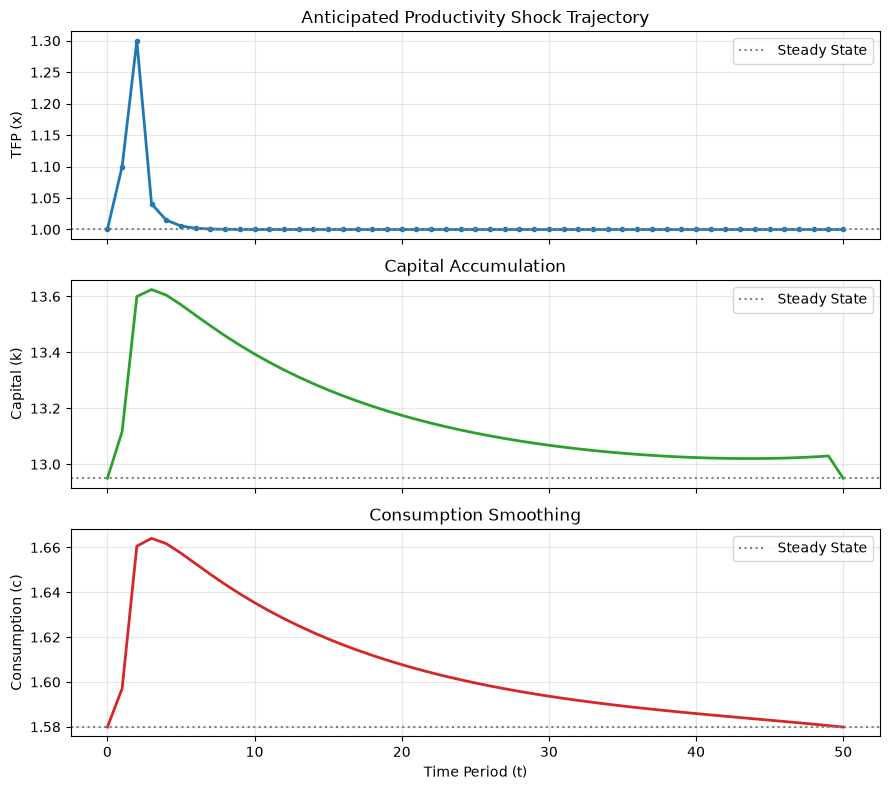

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

# Productivity path x_t
axes[0].plot(traj_df['t'], traj_df['x'], color='#1f77b4', lw=2, marker='o', markersize=3)
axes[0].axhline(model.steady_state['x'], color='gray', linestyle=':', label='Steady State')
axes[0].set_ylabel('TFP (x)')
axes[0].set_title('Anticipated Productivity Shock Trajectory')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Capital stock k_t
axes[1].plot(traj_df['t'], traj_df['k'], color='#2ca02c', lw=2)
axes[1].axhline(model.steady_state['k'], color='gray', linestyle=':', label='Steady State')
axes[1].set_ylabel('Capital (k)')
axes[1].set_title('Capital Accumulation')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Consumption c_t
axes[2].plot(traj_df['t'], traj_df['c'], color='#d62728', lw=2)
axes[2].axhline(model.steady_state['c'], color='gray', linestyle=':', label='Steady State')
axes[2].set_ylabel('Consumption (c)')
axes[2].set_xlabel('Time Period (t)')
axes[2].set_title('Consumption Smoothing')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


### Economic Insights:
1. **Consumption Smoothing**: Households foresee higher future productivity and immediately increase consumption at $t=1$, even though capital has not accumulated yet.
2. **Capital Deepening**: Higher productivity boosts the marginal product of capital, leading to rapid investment and capital accumulation peaking around $t=4-5$.
3. **Smooth Convergence**: As the shock decays, the economy smoothly converges back to its stationary steady state.


## 4. Experiment: Initial Condition Shock (Capital Disaster)

Deterministic models are ideal for analyzing recovery from a large initial disruption (e.g., a natural disaster destroying 40% of the capital stock).

We can set this up inline with `DynoModel(txt=...)`:


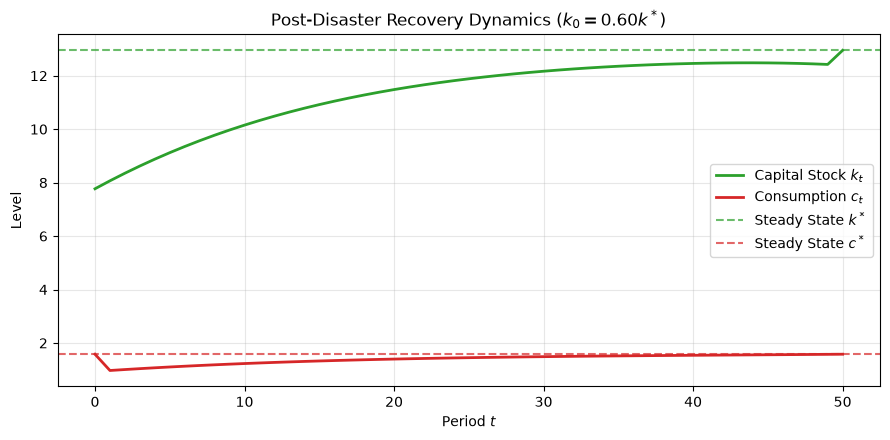

In [5]:
disaster_model_txt = '''
# Parameters
alph <- 0.50
gam  <- 0.50
delt <- 0.02
bet  <- 0.051
aa   <- 0.511
T    <- 50

# Steady-state values
x[~] <- 1.0
k[~] <- ((delt + bet) / (1.0 * aa * alph))^(1 / (alph - 1))
c[~] <- aa * k[~]^alph - delt * k[~]

# Dynamic equations
0 = c[t] + k[t] - aa*x[t]*k[t-1]^alph - (1 - delt)*k[t-1]
0 = c[t]^(-gam) - (1 + bet)^(-1) * (aa*alph*x[t+1]*k[t]^(alph-1) + 1 - delt) * c[t+1]^(-gam)

# Constant productivity path
x[1] <- 1.0
forall t, 2 <= t < T : x[t] <- 1.0

# Initial condition override: capital destroyed by 40%
k[0] <- 0.60 * k[~]
'''

disaster_model = DynoModel(txt=disaster_model_txt)

# Construct initial guess based on steady state with k[0] = 0.60 * k_ss
v0 = np.concatenate(disaster_model.__steady_state_vectors__)[None, :].repeat(51, axis=0)
k_idx = disaster_model.symbols['variables'].index('k')
v0[:, k_idx] = disaster_model.steady_state['k']
v0[0, k_idx] = 0.60 * disaster_model.steady_state['k']

disaster_traj = deterministic_solve(disaster_model, x0=v0, verbose=False)

# Plot recovery trajectory
plt.figure(figsize=(9, 4.5))
plt.plot(disaster_traj['t'], disaster_traj['k'], label='Capital Stock $k_t$', lw=2, color='#2ca02c')
plt.plot(disaster_traj['t'], disaster_traj['c'], label='Consumption $c_t$', lw=2, color='#d62728')
plt.axhline(disaster_model.steady_state['k'], color='#2ca02c', linestyle='--', alpha=0.7, label='Steady State $k^*$')
plt.axhline(disaster_model.steady_state['c'], color='#d62728', linestyle='--', alpha=0.7, label='Steady State $c^*$')
plt.title('Post-Disaster Recovery Dynamics ($k_0 = 0.60 k^*$)')
plt.xlabel('Period $t$')
plt.ylabel('Level')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
